In [ ]:
# ---------------- IMPORTS ----------------


import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import time
import sys
import shutil
import math
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split



# ---------------- HYPERPARAMETERS ----------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
TRAIN_TEST_SPLIT = 0.8
LEARNING_RATE = 1e-4

# ---------------- PATHS (Kaggle dataset paths) ----------------
fall_class_path = "/kaggle/input/datasets/brahimachour2/datasetimgchute23/DATASET_EXPP2img/Chute"
other_class_path = "/kaggle/input/datasets/brahimachour2/datasetimgchute23/DATASET_EXPP2img/Non-Chute"

# ---------------- TEMPORARY DIRECTORY PREPARATION ----------------
base_dir = "/kaggle/working/fall_classification"
os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

train_fall = os.path.join(train_dir, "fall")
train_other = os.path.join(train_dir, "other")
test_fall = os.path.join(test_dir, "fall")
test_other = os.path.join(test_dir, "other")
for folder in [train_fall, train_other, test_fall, test_other]:
    os.makedirs(folder, exist_ok=True)

# ---------------- DATA ORGANIZATION FUNCTION ----------------
print("[INFO] Organizing data...")

def organize_data(source_path, class_name):
    files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f))]
    train_files, test_files = train_test_split(files, train_size=TRAIN_TEST_SPLIT, random_state=42)
    for f in train_files:
        shutil.copy(os.path.join(source_path, f), os.path.join(train_dir, class_name, f))
    for f in test_files:
        shutil.copy(os.path.join(source_path, f), os.path.join(test_dir, class_name, f))

organize_data(fall_class_path, "fall")
organize_data(other_class_path, "other")

# ---------------- IMAGE GENERATORS ----------------
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ---------------- MODEL CREATION FUNCTION ----------------
def create_enhanced_model(input_shape=(224, 224, 3)):
    # Pre-trained backbone
    backbone = ConvNeXtBase(include_top=False, weights='imagenet', input_shape=input_shape, pooling=None)
    backbone.trainable = False  # Initial freeze to avoid fine-tuning (and OOM)

    # Spatial attention module (CBAM-like)
    def spatial_attention(x):
        avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3, keepdims=True))(x)
        max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=3, keepdims=True))(x)
        concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
        cbam = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)
        return layers.Multiply()([x, cbam])

    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = spatial_attention(x)

    # Dynamic reshape into (batch, sequence_length, channels)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)

    # Temporal branch (sequence simulation via frames)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Attention()([x, x])  # self-attention

    # Classification
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ---------------- INITIALIZATION AND COMPILATION ----------------
model = create_enhanced_model(IMG_SIZE + (3,))

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall'), 'accuracy']
)

model.summary()

# ---------------- CALLBACKS ----------------
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, monitor='val_loss')
]

# ---------------- TRAINING (INITIAL TRAINING ONLY) ----------------
print("[INFO] Starting initial training...")
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(test_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ---------------- EVALUATION ----------------
print("[INFO] Final evaluation...")
test_loss, test_auc, test_recall, test_acc = model.evaluate(test_generator, steps=validation_steps)
print(f"\nAccuracy on test set: {test_acc*100:.2f}%")
print(f"AUC: {test_auc*100:.2f}%")
print(f"Recall: {test_recall*100:.2f}%")

# Predictions for confusion matrix and report
predictions = model.predict(test_generator, steps=validation_steps)
pred_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes[:len(pred_classes)]  # ensure same size

print("\nClassification report:")
print(classification_report(true_classes, pred_classes, target_names=['other', 'fall']))





# ---------------- MODEL SAVING ----------------
model.save('/kaggle/working/fall_detection_experience2_model.keras')
print("[INFO] Model saved as 'fall_detection_enhanced_model.keras'")

[INFO] Organizing data...
Found 983 images belonging to 2 classes.
Found 246 images belonging to 2 classes.


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base       │ (None, 7, 7,      │ 87,566,464 │ input_layer_11[0… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 7, 2)   │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ convnext_base[0]… │
│ (Multiply)          │ 1024)             │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, None,      │          0 │ multiply_1[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, None, 256) │    886,272 │ lambda_5[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, None, 256) │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,518,884 (337.67 MB)

 Trainable params: 952,420 (3.63 MB)

 Non-trainable params: 87,566,464 (334.04 MB)

[INFO] Starting initial training...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7558 - auc: 0.8152 - loss: 0.4877 - recall: 0.9393 - val_accuracy: 0.9065 - val_auc: 0.9638 - val_loss: 0.3295 - val_recall: 0.9231 - learning_rate: 1.0000e-04
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8993 - auc: 0.9608 - loss: 0.2762 - recall: 0.9186 - val_accuracy: 0.9024 - val_auc: 0.9665 - val_loss: 0.2410 - val_recall: 0.9408 - learning_rate: 1.0000e-04
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9237 - auc: 0.9730 - loss: 0.2067 - recall: 0.9334 - val_accuracy: 0.9106 - val_auc: 0.9716 - val_loss: 0.2077 - val_recall: 0.9349 - learning_rate: 1.0000e-04
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9318 - auc: 0.9791 - loss: 0.1737 - recall: 0.9408 - val_accuracy: 0.8984 - val_auc: 0.9750 - val_loss: 0.1926 - val_recall: 0.9053 - learning_rate: 1.0000e-04
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9491

[INFO] Using model already loaded in session.
[INFO] Organizing test data...
Found 246 images belonging to 2 classes.
[INFO] Generating predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 933ms/step
[INFO] Total predictions: 246
[INFO] Other class samples: 77
[INFO] Fall class samples: 169


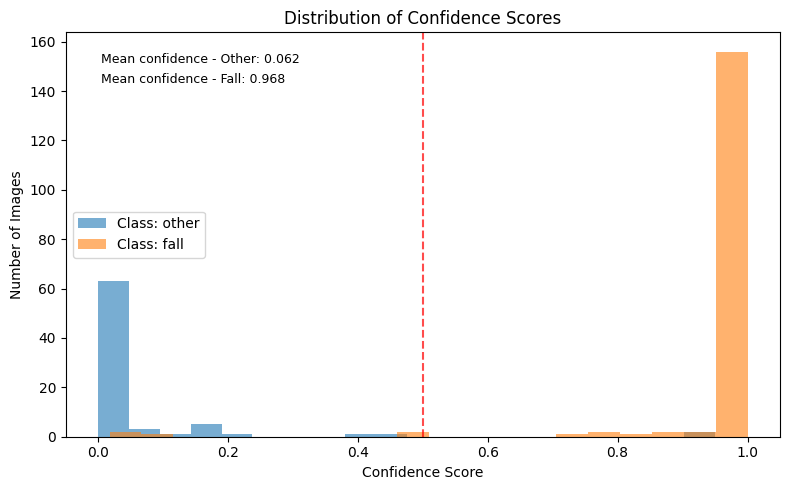

[INFO] Histogram saved to /kaggle/working/confidence_histogram.png


In [ ]:
# -*- coding: utf-8 -*-
# Confidence Score Distribution Histogram

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ----------------- CONFIG -----------------
fall_class_path = "/kaggle/input/datasets/brahimachour2/datasetimgchute23/DATASET_EXPP2img/Chute"
other_class_path = "/kaggle/input/datasets/brahimachour2/datasetimgchute23/DATASET_EXPP2img/Non-Chute"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ----------------- Load model -----------------
try:
    model
    print("[INFO] Using model already loaded in session.")
except NameError:
    model_path = "/kaggle/working/fall_detection_experience2_model.keras"
    if os.path.exists(model_path):
        print(f"[INFO] Loading model from '{model_path}'...")
        model = tf.keras.models.load_model(model_path)
    else:
        raise RuntimeError("No model found in session and 'fall_detection_experience2_model.keras' is missing. "
                           "Please run the training script first or upload the model.")

# ----------------- Prepare data -----------------
import shutil
from sklearn.model_selection import train_test_split

# Create temporary directories
base_dir = "/kaggle/working/confidence_analysis"
test_dir = os.path.join(base_dir, "test")
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(test_dir, "fall"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "other"), exist_ok=True)

# Organize data - only need test set
def organize_test_data(source_path, class_name):
    files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f))]
    _, test_files = train_test_split(files, train_size=0.8, random_state=42)
    for f in test_files:
        shutil.copy(os.path.join(source_path, f), os.path.join(test_dir, class_name, f))

print("[INFO] Organizing test data...")
organize_test_data(fall_class_path, "fall")
organize_test_data(other_class_path, "other")

# Create test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ----------------- Get predictions -----------------
print("[INFO] Generating predictions...")
pred_probs = model.predict(test_generator, steps=len(test_generator), verbose=1)
pred_probs = pred_probs.flatten()

# Get true classes
true_classes = test_generator.classes[:len(pred_probs)]

print(f"[INFO] Total predictions: {len(pred_probs)}")
print(f"[INFO] Other class samples: {np.sum(true_classes == 0)}")
print(f"[INFO] Fall class samples: {np.sum(true_classes == 1)}")

# ----------------- Plot histogram -----------------
plt.figure(figsize=(8, 5))
plt.hist(pred_probs[true_classes == 0], bins=20, alpha=0.6, label='Class: other')
plt.hist(pred_probs[true_classes == 1], bins=20, alpha=0.6, label='Class: fall')

plt.xlabel('Confidence Score')
plt.ylabel('Number of Images')
plt.title('Distribution of Confidence Scores')
plt.legend()

# Add vertical line at decision threshold
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Decision threshold (0.5)')

# Add some statistics as text
other_mean = np.mean(pred_probs[true_classes == 0])
fall_mean = np.mean(pred_probs[true_classes == 1])
plt.text(0.05, 0.95, f'Mean confidence - Other: {other_mean:.3f}',
         transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')
plt.text(0.05, 0.90, f'Mean confidence - Fall: {fall_mean:.3f}',
         transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')

plt.tight_layout()
plt.savefig("/kaggle/working/confidence_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Histogram saved to /kaggle/working/confidence_histogram.png")

